## Testing quenching.py

## Import and Preprocess

In [1]:
# ================================
# eLoss-only notebook (pub styling)
# ================================
import numpy as np, matplotlib.pyplot as plt, sys
from dataclasses import replace
sys.path.append("../code")

from glauber import SystemSpec, OpticalGlauber
from quenching import QuenchParams, xA0_from_L, qhat_of_x, _l2, dpt_side
from cross_sections import (SigmaPPTable, sigma_avg_in_bin, RpA_vs_centrality, plot_r_vs_y_in_bins, plot_r_vs_pt_in_bins, average_R,
                            L_eff_minbias)
# your Particle and alpha_s providers:
from particle import Particle              # assumes .d2sigma_pp, .mT, .y_max, .xA, .xB implemented
from coupling import alpha_s_provider      # your running/constant αs factory

## Particle & Set up

In [2]:
# 1) Systems & Glauber
roots = 8160.0
spec_pA = SystemSpec(system="pA", roots_GeV=roots, A=208, sigma_nn_mb=71.0)
gl      = OpticalGlauber(spec_pA, verbose=False)

In [3]:
# 2) Particles
P_charmonia = Particle(family="charmonia",  state="avg")     # average charmonia (or "Jpsi", etc.)
P_bottomonia = Particle(family="bottomonia", state="avg")     # average bottomonia (or "Upsilon(1S)", etc.)

In [4]:
# coupling constant provider
alpha_run = alpha_s_provider(mode="running", loops=4, method="ode")
# alpha_cst = alpha_s_provider(mode="constant", alpha0=0.326)
alpha_cst = alpha_s_provider(mode="constant", alpha0=0.50)

alpha_s = alpha_cst

In [5]:
## Quenching parameter setting
qp_base   = QuenchParams(
    qhat0=0.075, lp_fm=1.5,
    LA_fm=L_eff_minbias(gl, "pA"), LB_fm=L_eff_minbias(gl, "pA"),
    lambdaQCD=0.308, roots_GeV=roots,
    alpha_of_mu=alpha_s,
    alpha_scale="mT"   # matches C++
)

In [ ]:
# σ_pp table (big speedup for scans)
import numpy as np
y_tab  = np.linspace(-5.0, 5.0, 41)
pt_tab = np.linspace(0.0,  25.0, 101)
pp_tab_chi = SigmaPPTable(P_charmonia, roots, y_tab, pt_tab)
pp_tab_bot = SigmaPPTable(P_bottomonia, roots, y_tab, pt_tab)

In [ ]:
# Define centrality bins (fractions)
cent_edges = (0.0, 0.2, 0.4, 0.6, 0.8, 1.0)   # 0-20-40-60-80-100%

# Glauber (pPb @ LHC), then get min-bias L_eff
spec = SystemSpec(system="pA", roots_GeV=8160.0, A=208, sigma_nn_mb=71.0)
gl = OpticalGlauber(spec, verbose=True)
# For your prints (like the C++ pretty printer)
# gl.print_pA_centrality_table([0,20,40,60,80,100], method="binomial")
# gl.print_pA_centrality_table([0,20,40,60,80,100], method="optical") 
# Grids
pT = np.linspace(0.0, 30.0, 241)
y  = np.linspace(-5.0, 5.0, 201)

# Centrality-binned L_eff using A&P binomial method (Eq. B.9)
bins = [(0,20),(20,40),(40,60),(60,80),(80,100)]
LA_by_bin = gl.leff_bins_pA(bins, rho0_fm3=0.17, Lp_fm=1.5, method="binomial")
# Optical L_Eff
LA_by_bin_opt = gl.leff_bins_pA(bins, method="optical")

In [11]:
qpar_run = qp_base

## Cross Sections

In [ ]:
y_rng = (-5,5)
pt_rng = (0,20)
cent_edges = (0.0,0.2,0.4,0.6,0.8,1.0)
for P,label in [(P_charmonia,"J/psi"), (P_bottomonia,"Upsilon")]:
    rows=[]
    for L,R in zip(cent_edges[:-1], cent_edges[1:]):
        LA = gl.leff_bin_pA(L,R)
        qp = QuenchParams(qhat0=0.075, lp_fm=1.5,
            LA_fm=LA, LB_fm=LA,
            lambdaQCD=0.308, roots_GeV=roots,
            alpha_of_mu=alpha_s,
            alpha_scale="mT"   
        )
        # val_pp = sigma_avg_in_bin(P, roots, qp, y_rng, pt_rng, kind="pp")
        # val_pA = sigma_avg_in_bin(P, roots, qp, y_rng, pt_rng, kind="pA")
        
        rows.append((0.5*(L+R), val_pp, val_pA, val_pA/val_pp))
    # plot val_pA (or AA) stacked by species, and RpA as lines


KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_pp_pA_RpA_from_rows(rows, label, cent_edges, *,
                             y_rng=(-5,5), pt_rng=(0,20),
                             mb_exact=None,  # pass a float to show exact min-bias line
                             units=r"$\langle d^2\sigma/dy\,dp_T\rangle$"):
    """
    rows: [(cent_mid_frac, sigma_pp, sigma_pA, RpA), ...]
    cent_edges: iterable of edges in [0..1], e.g. (0.0,0.1,0.2,...,1.0)
    mb_exact: float or None  -> if provided, draw exact min-bias line for σ_pA
    """
    # --- unpack ---
    cent_mid, sig_pp, sig_pA, rpa = map(np.array, zip(*rows))
    cent_edges = np.asarray(cent_edges, float)
    left  = 100.0*cent_edges[:-1]
    width = 100.0*np.diff(cent_edges)
    xmid  = 100.0*cent_mid

    # pp reference (constant)
    sig_pp_val = float(np.mean(sig_pp))

    # quick min-bias (width-weighted from bins)
    mb_est = float(np.average(sig_pA, weights=width))

    # figure
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

    # ---- Left: cross sections (pA bars + pp line) ----
    ax[0].bar(left, sig_pA, width=width, align="edge",
              edgecolor="black", alpha=0.85, label=r"$\langle\sigma_{pA}\rangle$ bins")
    ax[0].axhline(sig_pp_val, lw=2, ls="-.", label=r"$\langle\sigma_{pp}\rangle$")
    # min-bias lines
    ax[0].axhline(mb_est, lw=2, ls="--", label="MinBias (bin-weight est.)")
    if mb_exact is not None:
        ax[0].axhline(float(mb_exact), lw=2, ls=":", label="MinBias (exact L_eff)")
    ax[0].set(xlim=(0,100), xlabel="Centrality [%]",
              ylabel=f"{units}",
              title=f"{label}: ⟨σ⟩ in {y_rng} × {pt_rng} GeV")
    ax[0].legend(frameon=False)
    ax[0].grid(True, ls="--", alpha=0.35)

    # ---- Right: RpA vs centrality ----
    ax[1].plot(xmid, rpa, marker="o", lw=2)
    ax[1].axhline(1.0, lw=1.5, ls="--", alpha=0.6)
    ax[1].set(xlim=(0,100), ylim=(0.0, max(1.1, 1.05*np.max(rpa))),
              xlabel="Centrality [%]",
              ylabel=r"$R_{pA}$",
              title=f"{label}: $R_{{pA}}$ in {y_rng} × {pt_rng} GeV")
    ax[1].grid(True, ls="--", alpha=0.35)

    return fig, ax

In [ ]:
# exact min-bias for pA (uses your current modules)
LA_mb = float(gl.leff_minbias_pA())  # or gl.leff_minbias_pA(rho0_fm3=..., method=...)
qp_mb = QuenchParams(qhat0=0.075, lp_fm=1.5,
                     LA_fm=LA_mb, LB_fm=LA_mb,
                     lambdaQCD=0.308, roots_GeV=roots,
                     alpha_of_mu=alpha_s, alpha_scale="mT")
mb_exact = sigma_avg_in_bin(P_charmonia, roots, qp_mb, y_rng, pt_rng, kind="pA")

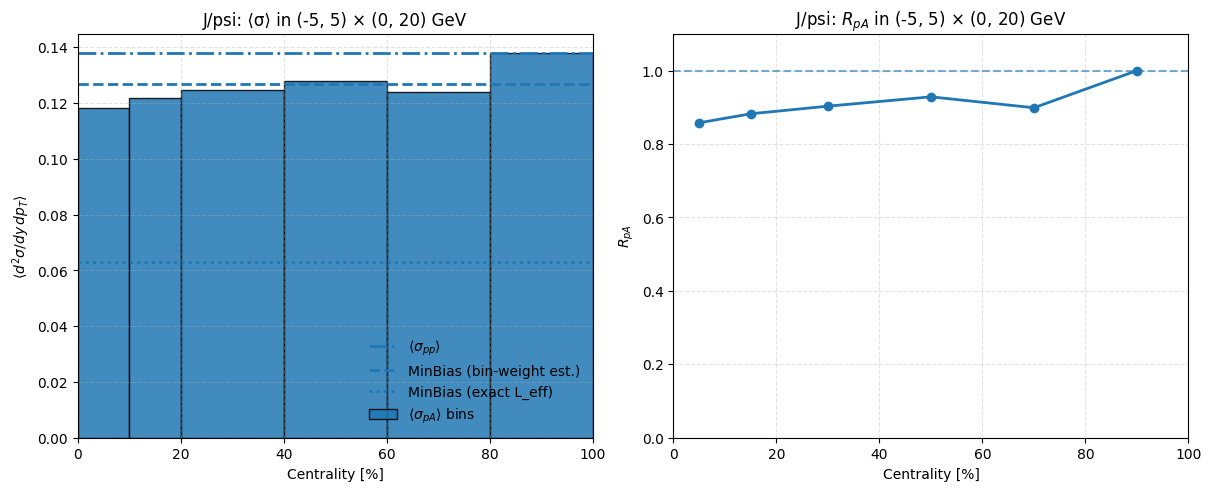

In [ ]:
fig, ax = plot_pp_pA_RpA_from_rows(rows, "J/psi", cent_edges,
                                   y_rng=y_rng, pt_rng=pt_rng,
                                   mb_exact=mb_exact,
                                   units=r"$\langle d^2\sigma/dy\,dp_T\rangle$")  
plt.show()

In [ ]:
from cross_sections import RpA

ModuleNotFoundError: No module named 'cross_sections'

## $R_{pA}$ and $R_{AA}$

In [ ]:
# --- compute RpA averages in each bin (y, pT windows are your analysis choice)
rows_chi = RpA_vs_centrality(
    P_charmonia, roots, qp_base, gl, cent_edges,
    y_range=(-5.0,5.0), pt_range=(0.0,20.0),
    Ny=32, Npt=64, method_pA="optical", table=pp_tab_chi
)
rows_bot = RpA_vs_centrality(
    P_bottomonia, roots, qp_base, gl, cent_edges,
    y_range=(-5.0,5.0), pt_range=(0.0,20.0),
    Ny=32, Npt=64, method_pA="optical", table=pp_tab_bot
)

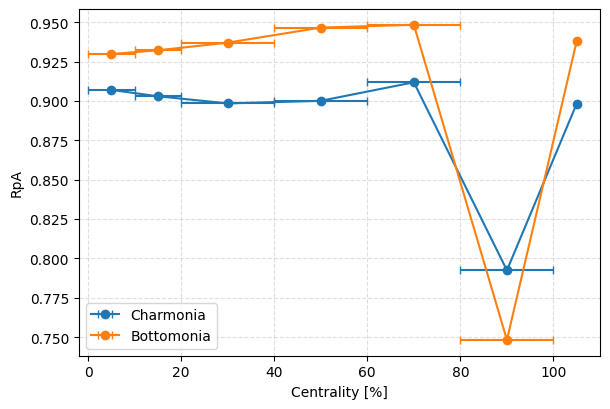

In [ ]:
# --- optional MinBias point (averaged with L_eff^MB)
def mb_point(P, tab):
    LAmb = L_eff_minbias(gl, "pA")
    qpmb = qp_base.__class__(**{**qp_base.__dict__, "LA_fm": LAmb, "LB_fm": LAmb})
    val  = average_R(P, roots, qpmb, (-5,5), (0.1,20.0), Ny=32, Npt=64, kind="pA", table=tab)
    return dict(cent_mid=105.0, xerr=0.0, RpA=val)   # plot at 105% to the right of 0–100

rows_chi_mb = rows_chi + [mb_point(P_charmonia, pp_tab_chi)]
rows_bot_mb = rows_bot + [mb_point(P_bottomonia, pp_tab_bot)]

# --- plot
def _plot(rows, label, ax):
    x = [r["cent_mid"] for r in rows]
    ex = [r["xerr"] for r in rows]
    y = [r["RpA"]    for r in rows]
    ax.errorbar(x, y, xerr=ex, fmt="o-", capsize=3, label=label)
    ax.set_xlim(-2, 110); ax.set_xlabel("Centrality [%]"); ax.set_ylabel("RpA"); ax.grid(True, ls="--", alpha=0.4)

fig, ax = plt.subplots(figsize=(6.2,4.2))
_plot(rows_chi_mb, "Charmonia", ax)
_plot(rows_bot_mb, "Bottomonia", ax)
ax.legend(); fig.tight_layout()

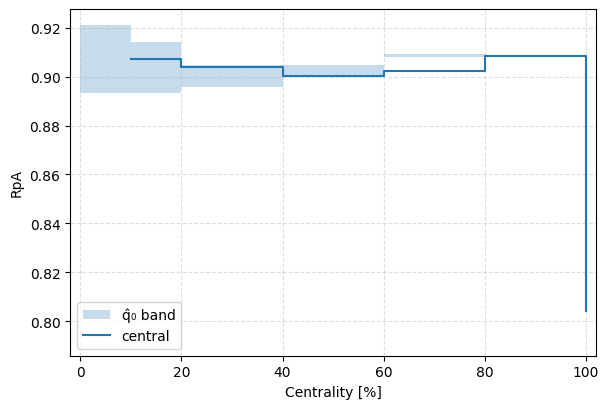

In [ ]:
from cross_sections import RpA_band_vs_centrality

band_chi = RpA_band_vs_centrality(
    P_charmonia, roots, gl, qp_base,
    q0_list=(0.05, 0.09),
    cent_edges=cent_edges,
    y_range=(-5,5), pt_range=(0.0,20.0),
    Ny=24, Npt=56, method_pA="optical", table=pp_tab_chi
)

# plot band
import matplotlib.pyplot as plt
xc   = [r["cent_mid"] for r in band_chi]
xerr = [r["xerr"]     for r in band_chi]
y    = [r["RpA"]      for r in band_chi]
lo   = [r["lo"]       for r in band_chi]
hi   = [r["hi"]       for r in band_chi]

fig, ax = plt.subplots(figsize=(6.2,4.2))
ax.fill_between([c - e for c,e in zip(xc,xerr)], lo, hi, step="post", alpha=0.25, label="q̂₀ band")
ax.step([c + e for c,e in zip(xc,xerr)], y, where="post", label="central")
ax.set_xlim(-2, 102); ax.set_xlabel("Centrality [%]"); ax.set_ylabel("RpA"); ax.grid(True, ls="--", alpha=0.4)
ax.legend(); fig.tight_layout()

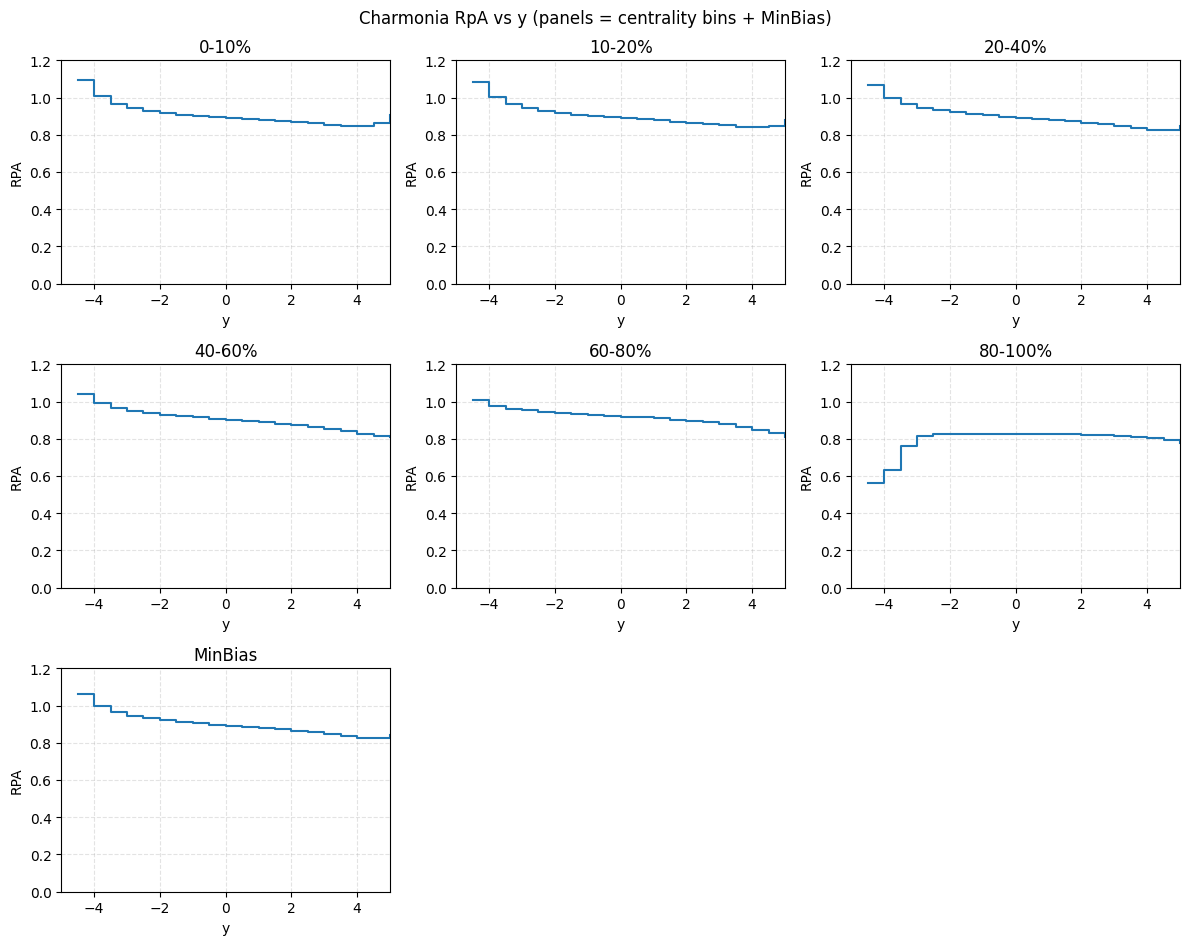

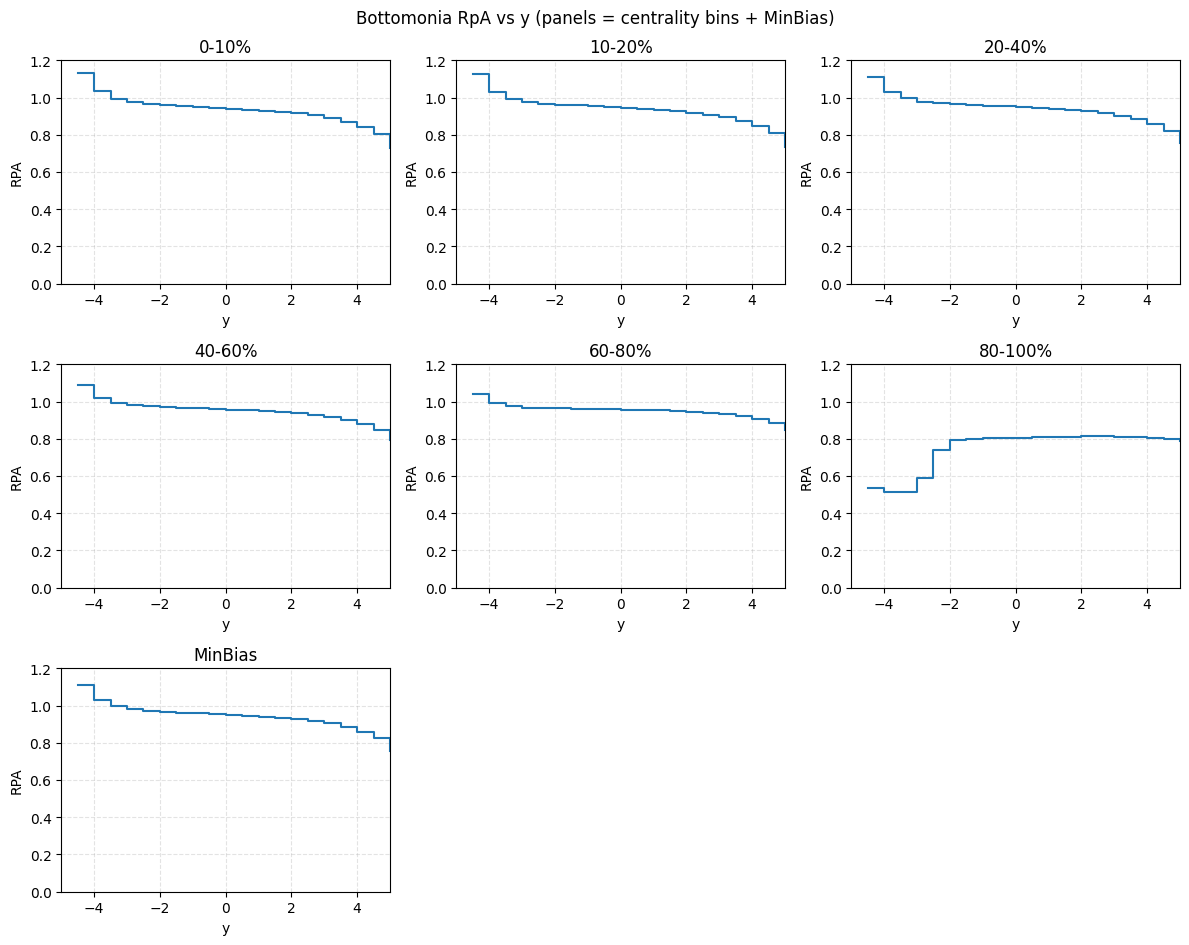

In [ ]:
# 6A) RpA vs rapidity, panels per centrality (+ MinBias tile at the end)
fig1, _ = plot_r_vs_y_in_bins(
    P_charmonia, roots, qp_base, gl,
    cent_edges=cent_edges, pt_range=(0.0, 20.0),
    y_edges=np.linspace(-5,5,21), which="pA", ncols=3, method_pA="optical",
    table=pp_tab_chi
)
fig1.suptitle("Charmonia RpA vs y (panels = centrality bins + MinBias)")
fig1.tight_layout()

fig2, _ = plot_r_vs_y_in_bins(
    P_bottomonia, roots, qp_base, gl,
    cent_edges=cent_edges, pt_range=(0.0, 20.0),
    y_edges=np.linspace(-5,5,21), which="pA", ncols=3, method_pA="optical",
    table=pp_tab_bot
)
fig2.suptitle("Bottomonia RpA vs y (panels = centrality bins + MinBias)")
fig2.tight_layout()

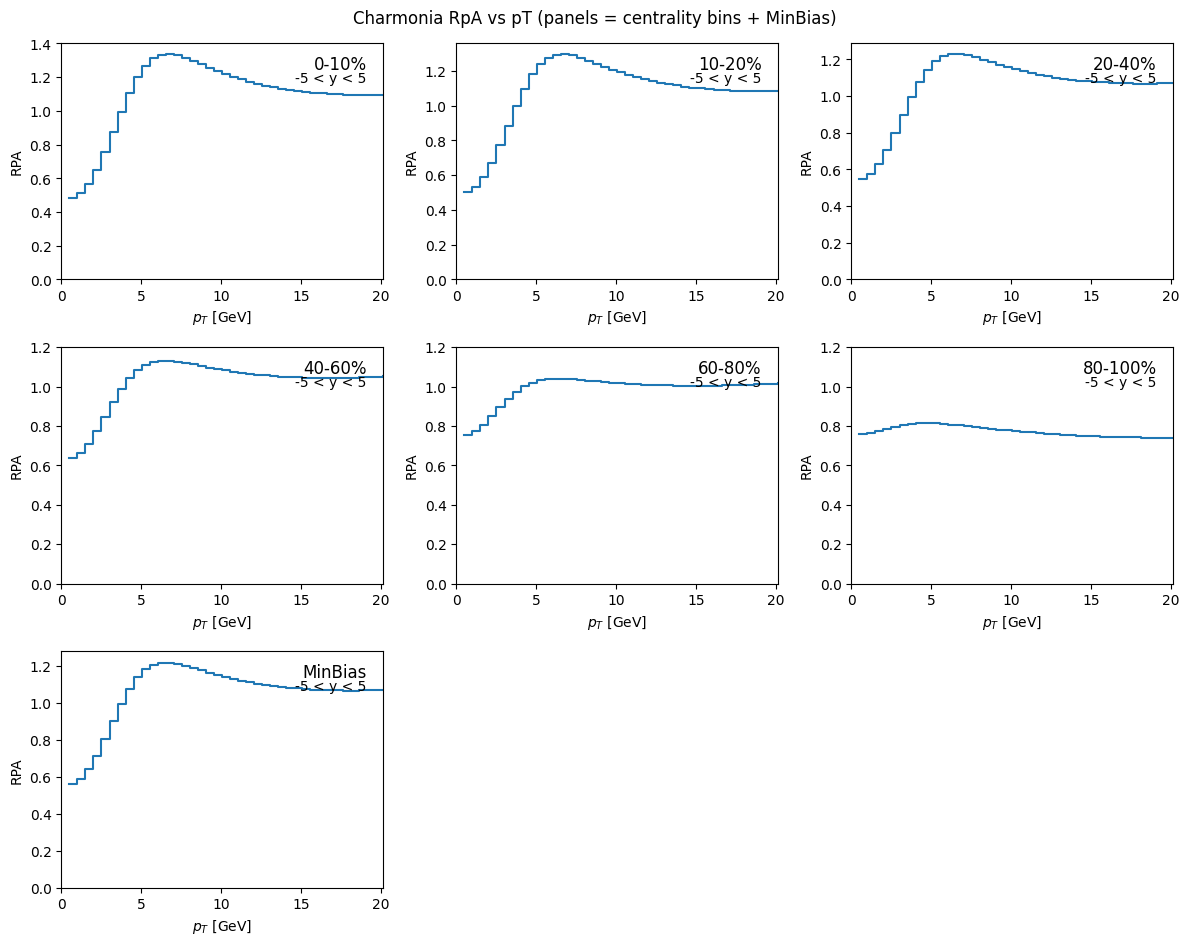

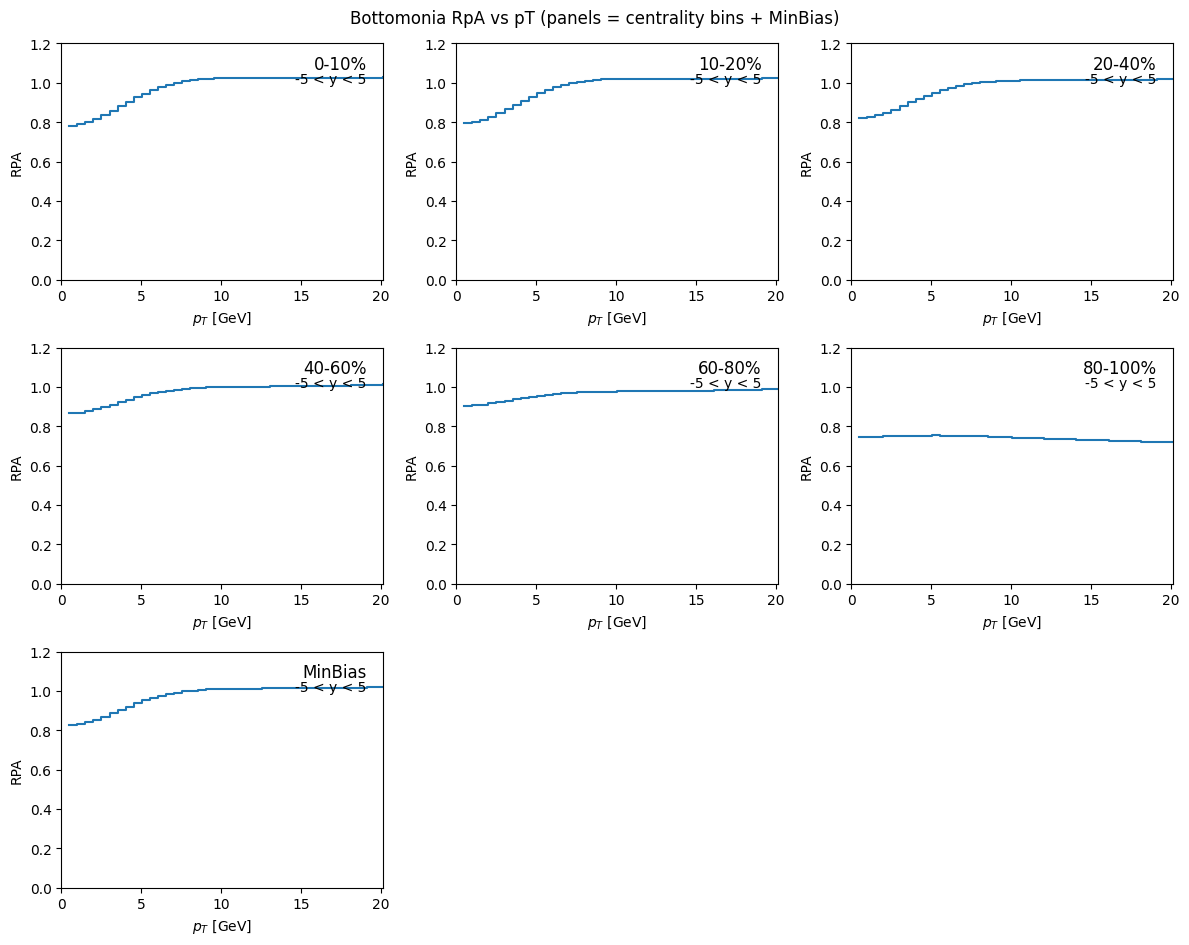

In [ ]:
# 6B) RpA vs pT, panels per centrality (+ MinBias tile)
fig3, _ = plot_r_vs_pt_in_bins(
    P_charmonia, roots, qp_base, gl,
    cent_edges=cent_edges, y_range=(-5,5),
    pt_edges=np.linspace(0.0, 20.10, 41), which="pA", ncols=3, method_pA="optical",
    table=pp_tab_chi
)
fig3.suptitle("Charmonia RpA vs pT (panels = centrality bins + MinBias)")
fig3.tight_layout()

fig4, _ = plot_r_vs_pt_in_bins(
    P_bottomonia, roots, qp_base, gl,
    cent_edges=cent_edges, y_range=(-5,5),
    pt_edges=np.linspace(0.0, 20.10, 41), which="pA", ncols=3, method_pA="optical",
    table=pp_tab_bot
)
fig4.suptitle("Bottomonia RpA vs pT (panels = centrality bins + MinBias)")
fig4.tight_layout()

In [ ]:
# Your defined windows and labels
Y_WINDOWS = [(-4.46,-2.96), (-1.37,0.43), (2.03,3.53)]
Y_LABELS  = ["-4.46 < y < -2.96", "-1.37 < y < 0.43", "2.03 < y < 3.53"]
# Tags for unique filenames
Y_FILES   = ["Back", "Mid", "For"]

Saved: charmonia_rpA_vs_pT_Back.png
Saved: bottomonia_rpA_vs_pT_Back.png
Saved: charmonia_rpA_vs_pT_Mid.png
Saved: bottomonia_rpA_vs_pT_Mid.png
Saved: charmonia_rpA_vs_pT_For.png
Saved: bottomonia_rpA_vs_pT_For.png


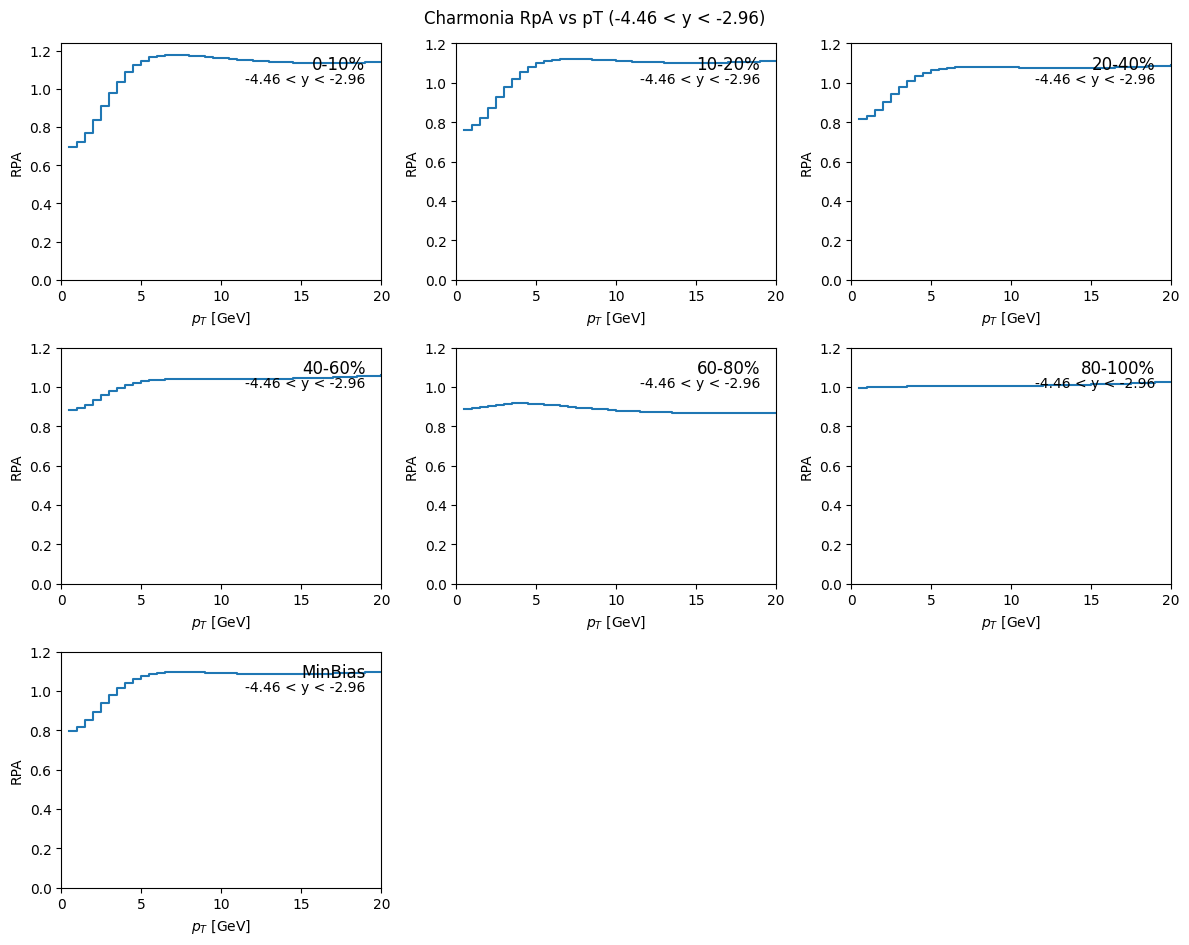

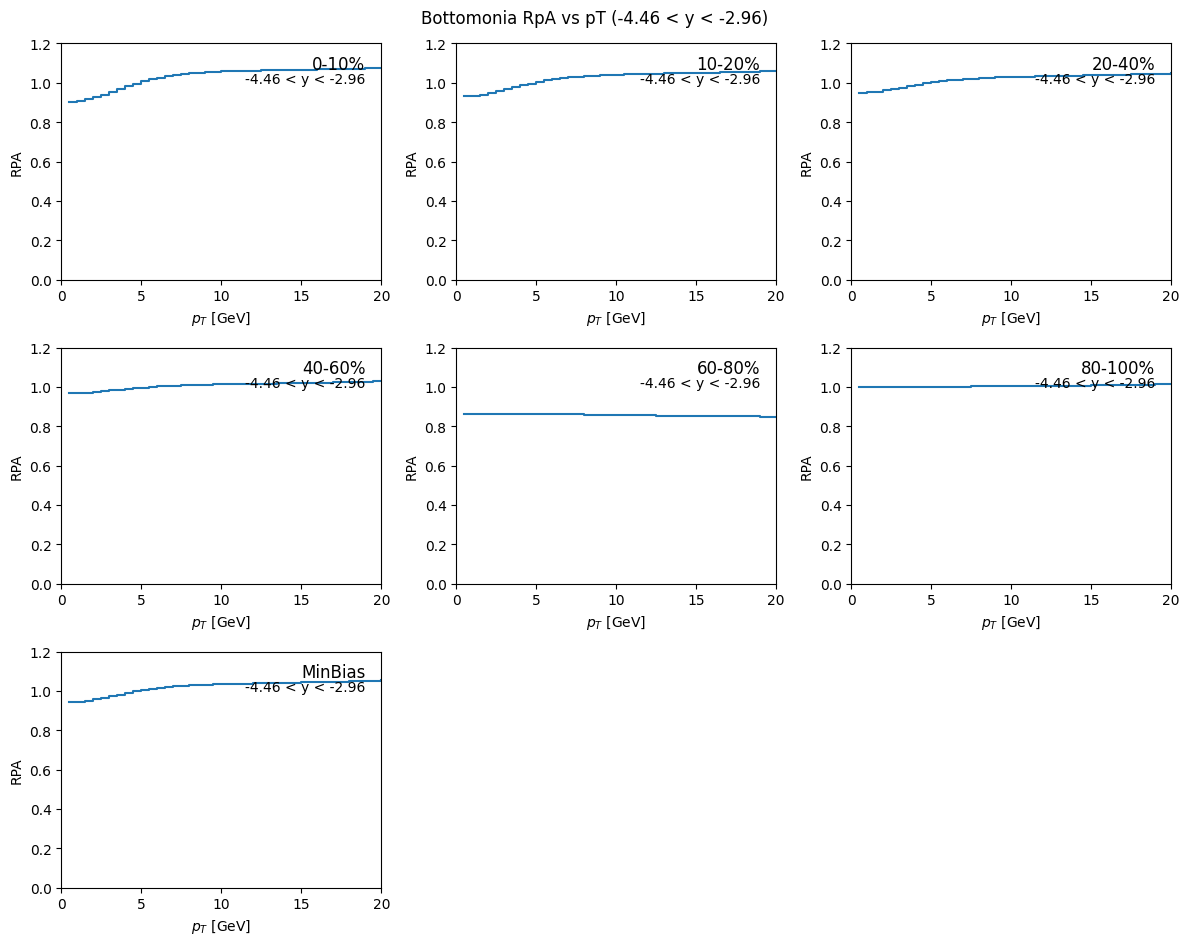

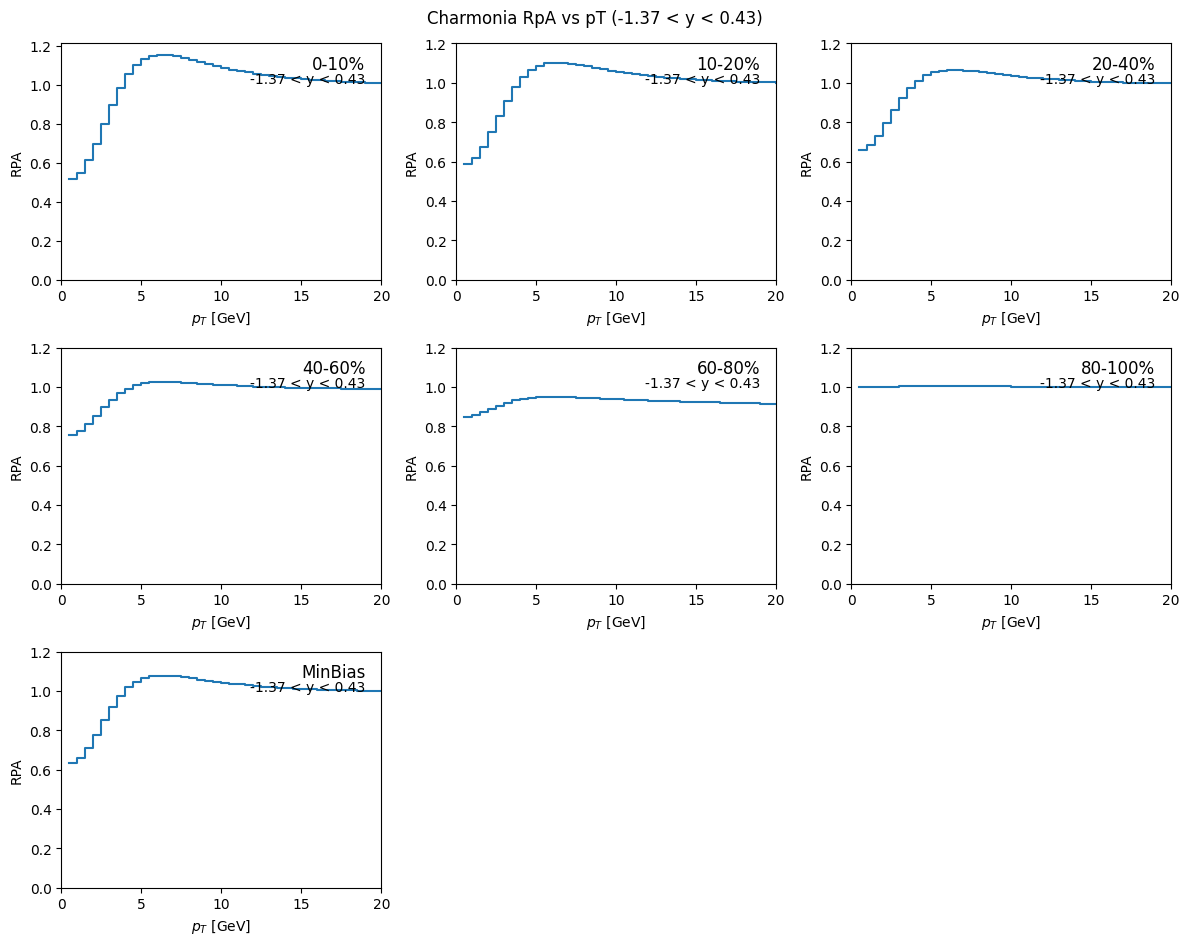

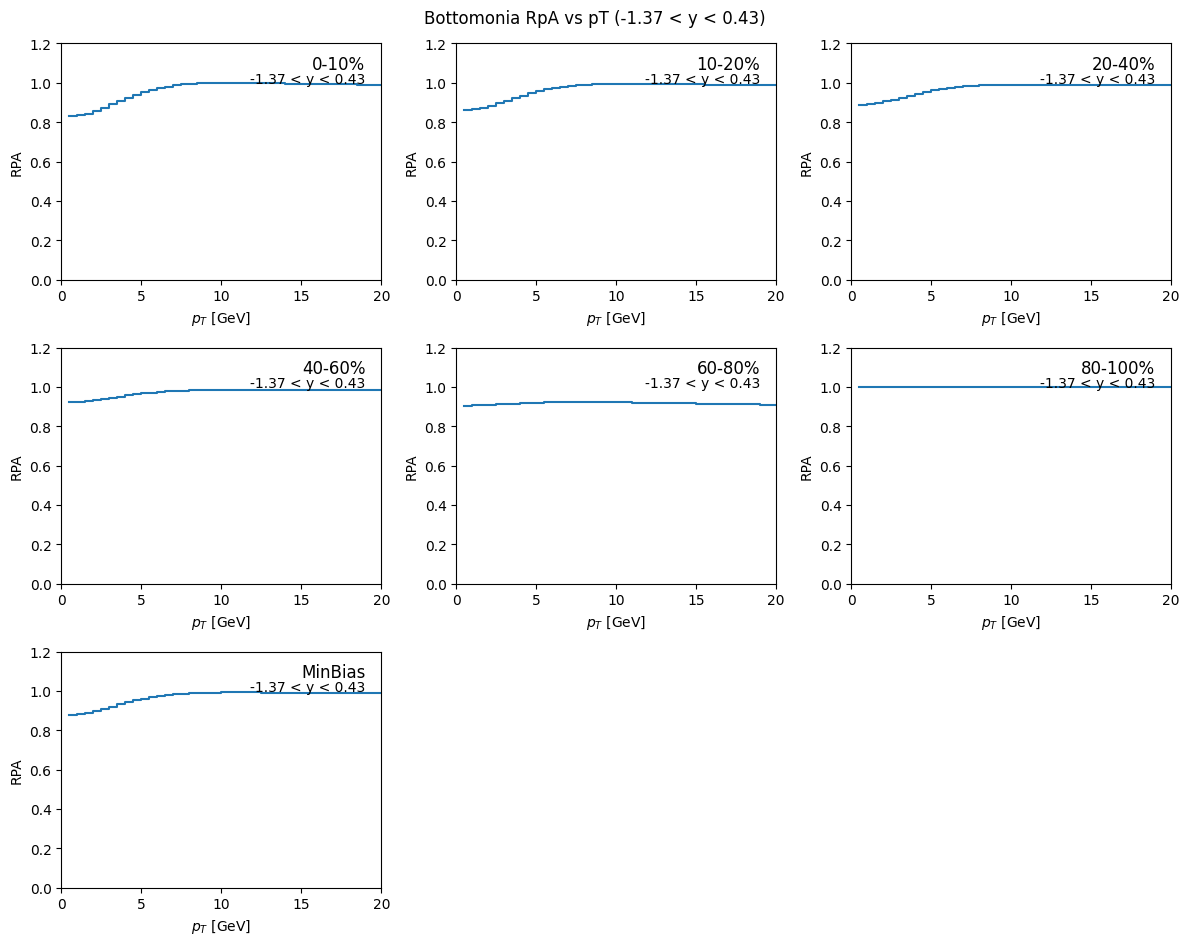

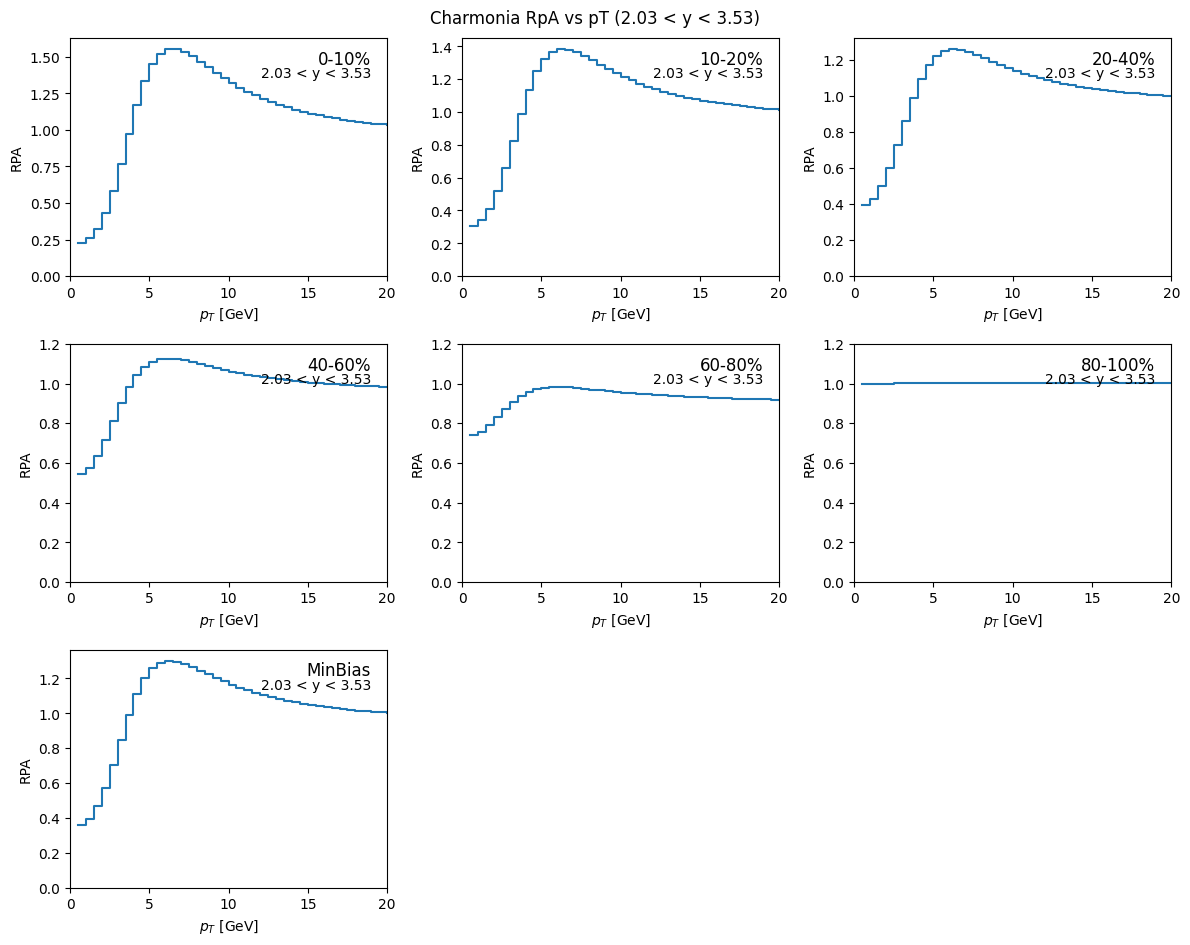

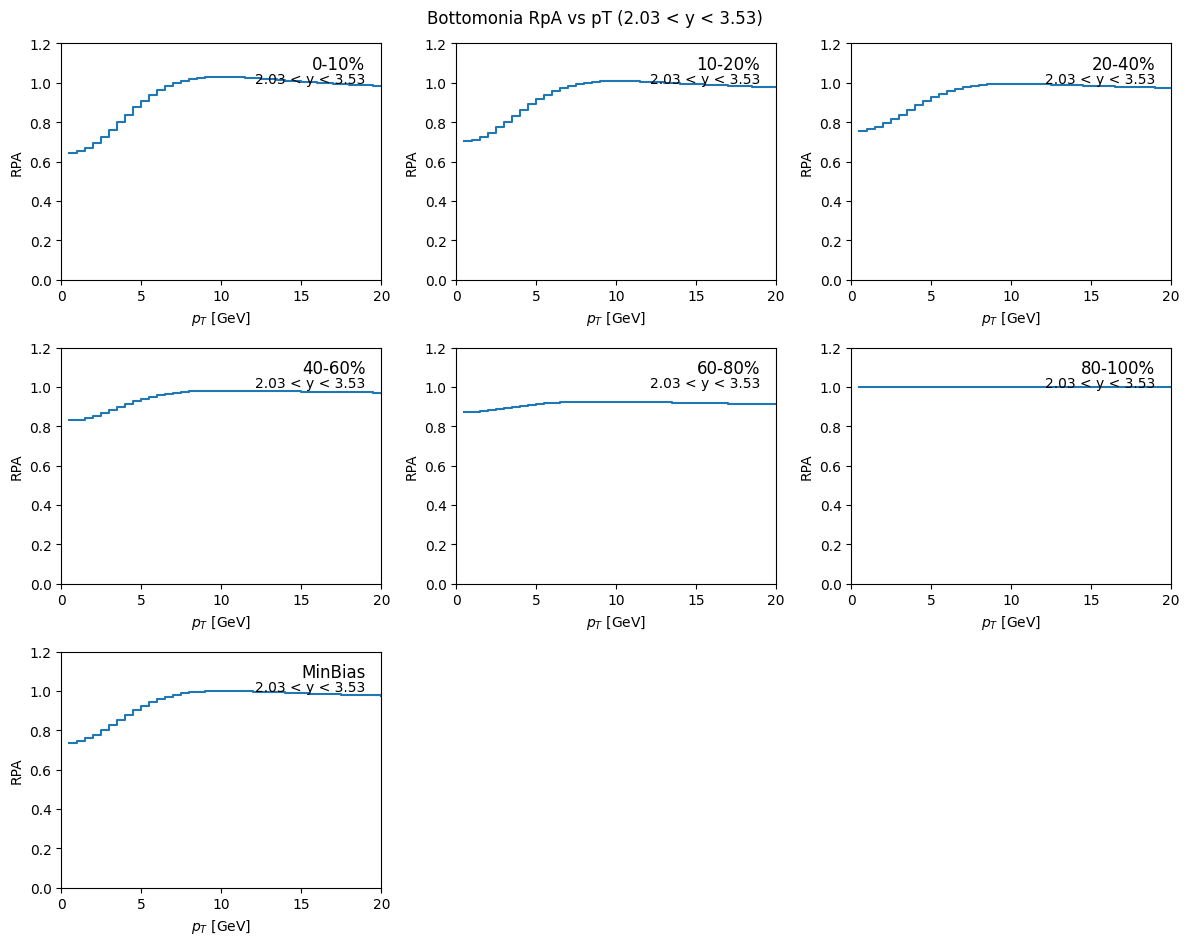

In [ ]:
all_figures = {}

# Loop over all three lists at once
for y_window, y_label, y_file_tag in zip(Y_WINDOWS, Y_LABELS, Y_FILES):

    # --- 1) Charmonia Plot for this y-window ---
    fig_chi, _ = plot_r_vs_pt_in_bins(
        P_charmonia, roots, qp_base, gl,
        cent_edges=cent_edges,
        y_range=y_window,  # <-- Set the specific y-range here
        pt_edges=np.linspace(0.0, 20.0, 41),
        which="pA",
        ncols=3,
        method_pA="binomial",
        table=pp_tab_chi
    )
    # Add the y-label to the title to distinguish the plots
    title_chi = f"Charmonia RpA vs pT ({y_label})"
    fig_chi.suptitle(title_chi)
    fig_chi.tight_layout()
    
    # --- Recommended: Save the figure with a unique name ---
    filename_chi = f"charmonia_rpA_vs_pT_{y_file_tag}.png"
    fig_chi.savefig(filename_chi, dpi=150, bbox_inches='tight')
    print(f"Saved: {filename_chi}")
    
    all_figures[f'chi_{y_file_tag}'] = fig_chi

    # --- 2) Bottomonia Plot for this y-window ---
    fig_bot, _ = plot_r_vs_pt_in_bins(
        P_bottomonia, roots, qp_base, gl,
        cent_edges=cent_edges,
        y_range=y_window,  # <-- Set the specific y-range here
        pt_edges=np.linspace(0.0, 20.0, 41),
        which="pA",
        ncols=3,
        method_pA="binomial",
        table=pp_tab_bot
    )
    # Add the y-label to the title
    title_bot = f"Bottomonia RpA vs pT ({y_label})"
    fig_bot.suptitle(title_bot)
    fig_bot.tight_layout()

    # --- Recommended: Save the figure with a unique name ---
    filename_bot = f"bottomonia_rpA_vs_pT_{y_file_tag}.png"
    fig_bot.savefig(filename_bot, dpi=150, bbox_inches='tight')
    print(f"Saved: {filename_bot}")
    
    all_figures[f'bot_{y_file_tag}'] = fig_bot